In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
import torch


In [4]:

med_tensor_path = '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data_3/med_tensors_output/med_tensor_100098_53.pt'
med_tensor = torch.load(med_tensor_path, weights_only=True)
med_tensor


(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([   0.,   10.,   20.,   30.,   40.,   50.,   60.,   70.,   80.,   90.,
          100.,  110.,  120.,  130.,  140.,  150.,  160.,  170.,  180.,  190.,
          200.,  210.,  220.,  230.,  240.,  250.,  260.,  270.,  280.,  290.,
          300.,  310.,  320.,  330.,  340.,  350.,  360.,  370.,  380.,  390.,
          400.,  410.,  420.,  430.,  440.,  450.,  460.,  470.,  480.,  490.,
          500.,  510.,  520.,  530.,  540.,  550.,  560.,  570.,  580.,  590.,
  

In [18]:
med_tensor[-1].max(dim=0)


torch.return_types.max(
values=tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0552,
        0.0000, 0.0055, 1.0000, 0.0000, 0.2572, 0.0000, 0.0254, 1.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]),
indices=tensor([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0, 35,  0,  0,  0,  0, 35,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0]))

In [6]:
import pickle
combined_tensors_metadata_path = '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data_3/ccombined_metadata.pickle'
combined_tensors_metadata = pickle.load(open(combined_tensors_metadata_path, 'rb'))
combined_tensors_metadata


{'source_metadata': {'med_metadata_path': '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data_3/med_tensors_output/med_tensors_metadata.pkl',
  'physio_metadata_path': '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data_3/physio_tensors_output/physio_tensors_metadata.pkl',
  'med_data_path': '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/trig_with_waveform.parquet'},
 'trajectories': {'100098_53': {'hadm_id': np.int64(100098),
   'traj_id': '100098_53',
   'action_cluster_id': 53,
   't0_time': Timestamp('2108-04-11 09:56:00'),
   'trajectory_end_time': Timestamp('2108-04-11 10:02:00'),
   'duration_minutes': 6.0,
   'medications_at_t0': {'NaCl 0.9%': 0.0551551490125,
    'Norepinephrine': 0.2571634169689814},
   'n_medications_at_t0': 2,
   'trigger_medications': ['NaCl 0.9%', 'Norepinephrine'],
   'n_trigger_medications': 2,
   'ic_tensor_path': None,
   'prediction_targets_path': None,
   'has_abp_mean': False,
   'has_cvp': False,
   'abp_mean_value': None,
   '

In [3]:
import pandas as pd
med_df = pd.read_parquet('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/trig_with_waveform.parquet')

In [5]:
med_df.head()


,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,patientweight,...,rate/weight_capped,rate/weight_norm,item_label,rate_norm,prev_rate,trigger,trigger_reason,action_cluster_id,action_cluster_size,action_cluster_rank
0,65411,100098,225158,01-Drips,Continuous Med,2108-04-11 09:56:00+00:00,2108-04-11 11:01:00+00:00,6.602113,mL/hour,64.0,...,0.103158,0.055155,NaCl 0.9%,0.055155,0.099358,False,,53,2,<NA>
1,65411,100098,221906,01-Drips,Continuous Med,2108-04-11 09:56:00+00:00,2108-04-11 11:01:00+00:00,0.110035,mcg/kg/min,64.0,...,0.110035,0.257163,Norepinephrine,0.257163,0.231630,False,,53,2,<NA>
2,65411,100098,225158,02-Fluids (Crystalloids),Continuous IV,2108-04-11 10:02:00+00:00,2108-04-12 21:44:00+00:00,5.000000,mL/hour,64.0,...,0.078125,0.041771,NaCl 0.9%,0.041771,0.055155,False,,59,1,<NA>
3,65411,100098,225158,01-Drips,Continuous Med,2108-04-11 11:01:00+00:00,2108-04-11 14:21:00+00:00,8.403035,mL/hour,64.0,...,0.131297,0.070200,NaCl 0.9%,0.070200,0.041771,True,uptitrate_gt25pct_abs>=0.02,53,2,1
4,65411,100098,221906,01-Drips,Continuous Med,2108-04-11 11:01:00+00:00,2108-04-11 14:21:00+00:00,0.140051,mcg/kg/min,64.0,...,0.140051,0.327312,Norepinephrine,0.327312,0.257163,True,uptitrate_gt25pct_abs>=0.02,53,2,2


In [3]:
numeric_sampl = pd.read_parquet('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/full_trajectories/full_waveform_199998_p027200-2119-02-20-14-48n.parquet')

In [6]:
import os
raw_total_numerics_dir = '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/full_trajectories'
numerics_files = os.listdir(raw_total_numerics_dir)
len(numerics_files)

8172

In [2]:
 
from typing import Optional, List

def load_medication_data(parquet_path: str) -> pd.DataFrame:
    """
    Load medication data for context tensor creation.

    Attempts parquet first (regardless of file extension), then falls back to
    pandas pickle, raw pickle, and a safe torch.load probe. Normalizes schema
    to include a 'rate/weight_normalized' column by mapping from common
    alternatives when needed.
    """
    print(f"Loading medication data from {parquet_path}...")

    df: Optional[pd.DataFrame] = None
    loaders_tried: List[str] = []

    # Always try parquet first; many .bin files are parquet saved with a custom extension
    try:
        df = pd.read_parquet(parquet_path)
    except Exception as e_parquet:
        loaders_tried.append(f"parquet:{e_parquet}")
        # Try pandas' pickle reader
        try:
            df = pd.read_pickle(parquet_path)
        except Exception as e_pd_pickle:
            loaders_tried.append(f"pd.read_pickle:{e_pd_pickle}")
            # Try raw pickle.load
            try:
                with open(parquet_path, 'rb') as f:
                    obj = pickle.load(f)
                if isinstance(obj, pd.DataFrame):
                    df = obj
                else:
                    raise TypeError("pickled object was not a pandas DataFrame")
            except Exception as e_raw_pickle:
                loaders_tried.append(f"pickle.load:{e_raw_pickle}")
                # Try a lightweight torch.load probe (in case the file was saved via torch)
                try:
                    import torch as _torch
                    obj = _torch.load(parquet_path, map_location="cpu")
                    if isinstance(obj, pd.DataFrame):
                        df = obj
                    elif isinstance(obj, dict) and 'data' in obj and isinstance(obj['data'], pd.DataFrame):
                        df = obj['data']
                    else:
                        raise TypeError("torch file did not contain a pandas DataFrame")
                except Exception as e_torch:
                    loaders_tried.append(f"torch.load:{e_torch}")

    if df is None:
        raise ValueError(
            f"Failed to load medication data from {parquet_path}. Tried: {loaders_tried}"
        )

    # Normalize column names where possible (map common variants to canonical)
    cols_lower_map = {c.lower(): c for c in df.columns}

    def _ensure_column(df_in: pd.DataFrame, canonical: str, candidates: List[str]) -> None:
        for cand in candidates:
            cand_lower = cand.lower()
            if cand_lower in cols_lower_map:
                src = cols_lower_map[cand_lower]
                if src != canonical and canonical not in df_in.columns:
                    df_in.rename(columns={src: canonical}, inplace=True)
                return

    _ensure_column(df, 'hadm_id', ['hadm_id', 'HADM_ID'])
    _ensure_column(df, 'start_time', ['start_time', 'START_TIME', 'STARTTIME'])
    _ensure_column(df, 'end_time', ['end_time', 'END_TIME', 'ENDTIME'])
    _ensure_column(df, 'item_label', ['item_label', 'ITEM_LABEL'])

    # Normalize rate column -> create 'rate/weight_normalized' if missing
    rate_canonical = 'rate/weight_normalized'
    if rate_canonical not in df.columns:
        # Candidates: common variants and fuzzy contains('rate') & contains('weight')
        candidate_order = [
            'rate_weight_normalized',
            'rate_per_kg',
            'rate_per_weight',
            'rate/weight',
            'rate',
            'RATE',
        ]
        picked_src: Optional[str] = None

        for cand in candidate_order:
            if cand in df.columns:
                picked_src = cand
                break
            if cand.lower() in cols_lower_map:
                picked_src = cols_lower_map[cand.lower()]
                break

        if picked_src is None:
            # Fuzzy search: any col name containing both 'rate' and 'weight'
            fuzzy = [c for c in df.columns if ('rate' in c.lower() and 'weight' in c.lower())]
            if len(fuzzy) > 0:
                picked_src = fuzzy[0]

        if picked_src is not None:
            df[rate_canonical] = pd.to_numeric(df[picked_src], errors='coerce')
        else:
            # As a last resort, if a plain 'rate' exists, use it
            if 'rate' in df.columns:
                df[rate_canonical] = pd.to_numeric(df['rate'], errors='coerce')

    # Validate required columns
    required_cols = ['hadm_id', 'start_time', 'end_time', 'item_label', rate_canonical]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(
            "Missing required medication columns: {}. Available: {}".format(
                missing_cols, list(df.columns)
            )
        )

    # Ensure datetime types and make tz-naive (UTC)
    if not pd.api.types.is_datetime64_any_dtype(df['start_time']):
        df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
    if not pd.api.types.is_datetime64_any_dtype(df['end_time']):
        df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')
    if pd.api.types.is_datetime64tz_dtype(df['start_time']):
        try:
            df['start_time'] = df['start_time'].dt.tz_convert('UTC').dt.tz_localize(None)
        except Exception:
            df['start_time'] = df['start_time'].dt.tz_localize(None)
    if pd.api.types.is_datetime64tz_dtype(df['end_time']):
        try:
            df['end_time'] = df['end_time'].dt.tz_convert('UTC').dt.tz_localize(None)
        except Exception:
            df['end_time'] = df['end_time'].dt.tz_localize(None)

    print(f"Loaded {len(df)} medication events")
    # Clean meds: remove Esmolol; cap each medication at mean + 4*std (per item)
    if 'item_label' in df.columns:
        # Drop Esmolol (case-insensitive)
        mask_esmo = df['item_label'].str.lower() == 'esmolol'
        if mask_esmo.any():
            df = df.loc[~mask_esmo].copy()
            print(f"Removed {int(mask_esmo.sum())} Esmolol rows")

        # Ensure numeric
        df[rate_canonical] = pd.to_numeric(df[rate_canonical], errors='coerce')

        # Compute per-medication caps at mean + 4*std
        stats = df.groupby('item_label')[rate_canonical].agg(['mean', 'std'])
        stats['cap'] = stats['mean'] + 4.0 * stats['std']

        # Merge caps and clip
        df = df.merge(stats['cap'].rename('___cap'), left_on='item_label', right_index=True, how='left')
        before = df[rate_canonical]
        df[rate_canonical] = before.clip(lower=0.0, upper=df['___cap'])
        num_clipped = int((before > df['___cap']).sum())
        df.drop(columns=['___cap'], inplace=True)
        if num_clipped > 0:
            print(f"Capped {num_clipped} medication rows at mean+4*std per item_label")

    return df

In [3]:
med_df = load_medication_data('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/mv_filtered.bin')

Loading medication data from /n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/mv_filtered.bin...
Loaded 32410 medication events
Removed 157 Esmolol rows
Capped 107 medication rows at mean+4*std per item_label


/n/netscratch/mzitnik_lab/Lab/rconci/tmp/ipykernel_2729023/3113312914.py:122: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df['start_time']):
/n/netscratch/mzitnik_lab/Lab/rconci/tmp/ipykernel_2729023/3113312914.py:127: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df['end_time']):


In [4]:
med_df.columns

Index(['subject_id', 'hadm_id', 'item_id', 'input_name', 'input_class',
       'start_time', 'end_time', 'rate', 'rate_uom', 'rate/weight',
       'item_label', 'rate_weight_norm', 'rate_norm', 'prev_rate', 'trigger',
       'trigger_reason', 'action_cluster_id', 'action_cluster_size',
       'action_cluster_rank', 'first', 'last', 'absolute_timestamp',
       'wf_time_delta_s', 'rate/weight_normalized'],
      dtype='object')

In [51]:
hadm_id = 101662
med_df[med_df['hadm_id'] == hadm_id]

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,rate/weight,...,trigger,trigger_reason,action_cluster_id,action_cluster_size,action_cluster_rank,first,last,absolute_timestamp,wf_time_delta_s,rate/weight_normalized


In [5]:
med_df[['hadm_id', 'start_time', 'end_time', 'item_label', 'rate/weight_normalized', 'trigger','action_cluster_id', 'absolute_timestamp' ]]

,hadm_id,start_time,end_time,item_label,rate/weight_normalized,trigger,action_cluster_id,absolute_timestamp
0,125124,2171-10-16 08:05:00,2171-10-16 08:17:00,Norepinephrine,0.100081,False,NaN,2171-10-16 08:05:01+00:00
1,125124,2171-10-16 08:17:00,2171-10-16 08:24:00,Norepinephrine,0.080050,False,NaN,2171-10-16 08:17:01+00:00
2,125124,2171-10-16 08:24:00,2171-10-16 08:39:00,Norepinephrine,0.060038,False,NaN,2171-10-16 08:24:01+00:00
3,125124,2171-10-16 08:39:00,2171-10-16 08:56:00,Norepinephrine,0.040033,True,9.0,2171-10-16 08:39:01+00:00
4,125124,2171-10-16 08:56:00,2171-10-16 09:35:00,Norepinephrine,0.080065,True,9.0,2171-10-16 08:56:01+00:00
...,...,...,...,...,...,...,...,...
32405,151454,2156-12-04 11:26:00,2156-12-04 12:26:00,Albumin 5%,3.511236,True,30.0,2156-12-04 11:25:56+00:00
32406,151454,2156-12-04 18:02:00,2156-12-04 18:32:00,Albumin 25%,1.404494,True,31.0,2156-12-04 18:01:56+00:00
32407,151454,2156-12-04 18:23:00,2156-12-04 19:23:00,Packed Red Blood Cells,4.915730,False,NaN,2156-12-04 18:22:56+00:00
32408,151454,2156-12-05 05:56:00,2156-12-05 08:14:00,Milrinone,0.250522,True,32.0,2156-12-05 05:55:56+00:00


In [7]:
triggers = med_df['trigger']
med_df['item_label'][triggers].value_counts()

item_label
Phenylephrine             1529
Norepinephrine            1031
NaCl 0.9%                  952
Nitroglycerin              626
LR                         594
Packed Red Blood Cells     261
Albumin 5%                 244
Hydralazine                220
Milrinone                  210
Nicardipine                150
Epinephrine                125
Albumin 25%                 92
Fresh Frozen Plasma         79
Vasopressin                 74
Labetalol                   55
Diltiazem                   47
Nitroprusside               22
Dopamine                    16
Mannitol                     6
Name: count, dtype: int64

In [14]:
n_clusters_total = med_df['action_cluster_id'].dropna().nunique()

# how many clusters have at least one trigger row?
n_clusters_with_trigger = med_df.loc[med_df['trigger'] == True, 'action_cluster_id'].dropna().nunique()

n_trigger_rows = (med_df['trigger'] == True).sum()

print("total clusters:", n_clusters_total)
print("clusters with >=1 trigger row:", n_clusters_with_trigger)
print("trigger rows (total):", n_trigger_rows)

total clusters: 176
clusters with >=1 trigger row: 176
trigger rows (total): 6333


In [8]:
import pandas as pd
import numpy as np
import pyarrow.dataset as ds
from typing import Dict, List, Tuple, Optional

def _merge_intervals(intervals: List[Tuple[pd.Timestamp, pd.Timestamp]]) -> List[Tuple[pd.Timestamp, pd.Timestamp]]:
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [intervals[0]]
    for s, e in intervals[1:]:
        last_s, last_e = merged[-1]
        if s <= last_e:
            merged[-1] = (last_s, max(last_e, e))
        else:
            merged.append((s, e))
    return merged

def _build_windows_from_triggers(
    med_df: pd.DataFrame,
    hadm_col: str = "hadm_id",
    trigger_col: str = "trigger",
    trigger_time_col: str = "start_time",
    pre_minutes: int = 60,
    post_minutes: int = 60,
) -> Dict[int, List[Tuple[pd.Timestamp, pd.Timestamp]]]:
    m = med_df.copy()
    m[trigger_time_col] = pd.to_datetime(m[trigger_time_col], utc=True, errors="coerce")
    m = m[(m[trigger_col] == True) & m[trigger_time_col].notna()]
    windows: Dict[int, List[Tuple[pd.Timestamp, pd.Timestamp]]] = {}
    pre = pd.Timedelta(minutes=pre_minutes)
    post = pd.Timedelta(minutes=post_minutes)

    for hadm, grp in m.groupby(hadm_col):
        raw = [(t - pre, t + post) for t in grp[trigger_time_col]]
        windows[hadm] = _merge_intervals(raw)
    return windows

def load_waveform_windows_parquet(
    waveform_path: str,
    med_df: pd.DataFrame,
    hadm_col: str = "hadm_id",
    wf_time_col: str = "absolute_timestamp",
    trigger_col: str = "trigger",
    trigger_time_col: str = "start_time",
    pre_minutes: int = 60,
    post_minutes: int = 60,
    columns: Optional[List[str]] = None,
    batch_size: int = 200_000,
) -> pd.DataFrame:
    # 1) Build windows
    windows = _build_windows_from_triggers(
        med_df, hadm_col, trigger_col, trigger_time_col, pre_minutes, post_minutes
    )
    if not windows:
        return pd.DataFrame()

    # 2) Open dataset
    dataset = ds.dataset(waveform_path, format="parquet")

    # Ensure timestamp + id always included
    needed = {hadm_col, wf_time_col}
    cols = list(needed.union(columns)) if columns else None

    # 3) Create scanner
    scanner = ds.Scanner.from_dataset(dataset, columns=cols, batch_size=batch_size)

    kept = []
    for record_batch in scanner.to_batches():
        chunk = record_batch.to_pandas()
        if chunk.empty:
            continue

        # ensure tz-aware UTC
        chunk[wf_time_col] = pd.to_datetime(chunk[wf_time_col], utc=True, errors="coerce")

        # boolean mask as a pandas Series (so we can OR by index)
        mask_all = pd.Series(False, index=chunk.index)

        # only hadm_ids that appear in this chunk and have windows
        hadms_in_chunk = pd.unique(chunk[hadm_col])
        for hadm in hadms_in_chunk:
            if hadm not in windows:
                continue

            # rows for this hadm
            idx = chunk[hadm_col] == hadm
            if not idx.any():
                continue

            # tz-aware Series of timestamps
            times = chunk.loc[idx, wf_time_col]

            # OR across this hadm's intervals using pandas between (tz-safe)
            keep_hadm = pd.Series(False, index=times.index)
            for start, end in windows[hadm]:  # start/end are tz-aware Timestamps (UTC)
                keep_hadm |= times.between(start, end, inclusive="both")

            # write back into the global mask
            mask_all.loc[keep_hadm.index] |= keep_hadm

        if mask_all.any():
            kept.append(chunk.loc[mask_all.values])

    out = pd.concat(kept, ignore_index=True) if kept else pd.DataFrame()
    out = out.sort_values([hadm_col, wf_time_col]).reset_index(drop=True)
    return out

In [ ]:
signal_cols = ["ABP MEAN", "NBP MEAN", "CVP", "HR", "RESP"]

segments = load_waveform_windows_parquet(
    waveform_path="/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/smoothed_numerics.bin",
    med_df=med_df,
    hadm_col="hadm_id",
    wf_time_col="absolute_timestamp",
    trigger_col="trigger",
    trigger_time_col="start_time",
    pre_minutes=60,
    post_minutes=60,
    columns=signal_cols,     # keep these + hadm_id + absolute_timestamp
    batch_size=200_000,
)
print(segments.shape)
segments.head()

(2572249, 7)
          HR  hadm_id   NBP MEAN       CVP       RESP   ABP MEAN  \
0  98.849847   100098  97.626603  8.448771  22.049807  89.084012   
1  98.747101   100098  97.624429  8.470903  21.988729  89.602771   
2  98.644355   100098  97.622256  8.493034  21.927652  90.121530   
3  98.541609   100098  97.620083  8.515166  21.866574  90.640290   
4  98.438863   100098  97.617909  8.537298  21.805496  91.159049   

         absolute_timestamp  
0 2108-04-12 11:03:08+00:00  
1 2108-04-12 11:03:18+00:00  
2 2108-04-12 11:03:28+00:00  
3 2108-04-12 11:03:38+00:00  
4 2108-04-12 11:03:48+00:00  


In [29]:
segments.columns

Index(['HR', 'hadm_id', 'NBP MEAN', 'CVP', 'RESP', 'ABP MEAN',
       'absolute_timestamp'],
      dtype='object')

In [30]:
from pathlib import Path
from typing import Iterable, Dict, List, Tuple, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------- TZ helpers ----------
def _ensure_series_utc(s: pd.Series) -> pd.Series:
    s = pd.to_datetime(s, errors="coerce")
    if getattr(s.dt, "tz", None) is None:
        return s.dt.tz_localize("UTC")
    return s.dt.tz_convert("UTC")

def _ensure_ts_utc(ts: pd.Timestamp) -> pd.Timestamp:
    ts = pd.to_datetime(ts, errors="coerce")
    if ts.tzinfo is None:
        return ts.tz_localize("UTC")
    return ts.tz_convert("UTC")

def _sanitize(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "-_." else "_" for ch in str(s))

def _qc_waveforms(wf_df: pd.DataFrame, signals):
    signals_list = list(signals)  # ensure list, not tuple
    wf = wf_df.copy()
    if "absolute_timestamp" not in wf.columns or "hadm_id" not in wf.columns:
        raise ValueError("waveform df must contain ['hadm_id', 'absolute_timestamp']")
    wf["absolute_timestamp"] = _ensure_series_utc(wf["absolute_timestamp"])

    # match requested names to available columns (case-insensitive)
    mapping, missing = _resolve_signal_names(signals_list, wf.columns)
    # ensure missing signals exist as NaN columns so the interface is stable
    for s in missing:
        wf[s] = np.nan

    # columns to keep: id, time, and the actual columns (or requested name if missing)
    actual_cols = [mapping.get(s, s) for s in signals_list]
    keep = ["hadm_id", "absolute_timestamp", *actual_cols]
    out = wf[keep].dropna(subset=["absolute_timestamp"]).sort_values(["hadm_id","absolute_timestamp"])
    return out

def _resolve_signal_names(requested, available_cols):
    """
    Map requested signal names to actual DataFrame columns (case-insensitive).
    Returns (mapping: dict[requested_name -> actual_col_name], missing: list[str]).
    """
    avail_map = {c.lower(): c for c in available_cols}
    mapping = {}
    missing = []
    for s in list(requested):
        key = s.lower()
        if key in avail_map:
            mapping[s] = avail_map[key]
        else:
            missing.append(s)
    return mapping, missing

In [16]:

def build_cluster_meta_20min_after_start(med_df: pd.DataFrame) -> pd.DataFrame:
    m = med_df.copy()
    m = m[m["action_cluster_id"].notna()]
    if m.empty:
        return pd.DataFrame(columns=["action_cluster_id","hadm_id","t0","cluster_type"])

    m["start_time"] = _ensure_series_utc(m["start_time"])
    m["end_time"]   = _ensure_series_utc(m["end_time"])

    # t0 per cluster = earliest trigger start; fallback to earliest start if cluster has no trigger rows
    t0_trigger = (m[m["trigger"] == True]
                  .groupby("action_cluster_id", as_index=True)["start_time"]
                  .min().rename("t0"))
    t0_fallback = m.groupby("action_cluster_id", as_index=True)["start_time"].min()
    t0_series = t0_trigger.combine_first(t0_fallback)

    hadm = m.groupby("action_cluster_id", as_index=True)["hadm_id"].agg(lambda x: x.iloc[0])
    delta = pd.Timedelta(minutes=20)

    types = []
    for cid, t0 in t0_series.items():
        sub = m[m["action_cluster_id"] == cid]
        window = (sub["start_time"] >= t0) & (sub["start_time"] <= t0 + delta)
        meds = tuple(sorted(map(str, sub.loc[window, "item_label"].dropna().unique())))
        types.append(meds)

    meta = pd.DataFrame({
        "action_cluster_id": t0_series.index.values,
        "hadm_id": hadm.loc[t0_series.index].values,
        "t0": t0_series.values,
        "cluster_type": types,
    })
    meta["t0"] = _ensure_series_utc(meta["t0"])
    return meta

meta = build_cluster_meta_20min_after_start(med_df)
print("meta clusters:", len(meta))

meta clusters: 176


In [18]:
type_counts_full = (meta["cluster_type"]
    .value_counts()
    .rename_axis("cluster_type")
    .reset_index(name="n_occurrences"))

# How many clusters include Phenylephrine in their type (any combo)?
n_clusters_with_ph = (meta["cluster_type"].apply(lambda t: "Phenylephrine" in t)).sum()

# How many unique clusters have a Phenylephrine *trigger row*?
n_clusters_ph_trig = (med_df[(med_df["trigger"] == True) & (med_df["item_label"] == "Phenylephrine")]
                      ["action_cluster_id"].dropna().nunique())

print("clusters including Phenylephrine in type:", n_clusters_with_ph)
print("clusters with a Phenylephrine trigger row:", n_clusters_ph_trig)

clusters including Phenylephrine in type: 71
clusters with a Phenylephrine trigger row: 132


In [19]:
type_counts_full

,cluster_type,n_occurrences
0,"(Phenylephrine,)",62
1,"(Norepinephrine,)",42
2,"(NaCl 0.9%,)",27
3,"(LR,)",7
4,"(Albumin 5%,)",6
5,"(Albumin 25%,)",6
6,"(Milrinone,)",4
7,"(Norepinephrine, Phenylephrine)",4
8,"(NaCl 0.9%, Phenylephrine)",2
9,"(Albumin 5%, LR)",2


In [21]:
from collections import Counter

counter = Counter()
for t in meta["cluster_type"]:
    counter.update(set(t))  # set() to avoid double counting same med within a cluster

per_med_cluster_counts = pd.DataFrame.from_records(
    [(k, v) for k, v in counter.items()],
    columns=["item_label", "n_clusters_where_present"]
).sort_values("n_clusters_where_present", ascending=False)

per_med_cluster_counts

,item_label,n_clusters_where_present
0,Phenylephrine,71
1,Norepinephrine,48
10,NaCl 0.9%,31
3,LR,10
5,Albumin 25%,8
4,Albumin 5%,8
6,Milrinone,4
7,Packed Red Blood Cells,4
2,Fresh Frozen Plasma,3
8,Epinephrine,2


In [22]:
def build_perturbation_dicts(meta: pd.DataFrame, top_n_types: Optional[int] = None):
    """
    Input: meta from build_cluster_meta_at_t0
    Returns:
      - type_counts: DataFrame with ['cluster_type','n_occurrences'] (optionally top-N)
      - occurrences_by_type: Dict[cluster_type_tuple -> List[(hadm_id, t0)]]
    """
    if meta.empty:
        return (pd.DataFrame(columns=["cluster_type","n_occurrences"]), {})

    type_counts = (
        meta["cluster_type"]
        .value_counts()
        .rename_axis("cluster_type")
        .reset_index(name="n_occurrences")
    )

    if top_n_types is not None and top_n_types > 0:
        keep = set(type_counts.head(top_n_types)["cluster_type"])
        type_counts = type_counts[type_counts["cluster_type"].isin(keep)]

    occurrences_by_type: Dict[Tuple[str, ...], List[Tuple[int, pd.Timestamp]]] = {}
    for ctype in type_counts["cluster_type"]:
        occ = meta.loc[meta["cluster_type"] == ctype, ["hadm_id","t0"]]
        occurrences_by_type[ctype] = [
            (int(h), _ensure_ts_utc(t)) for h, t in occ.itertuples(index=False, name=None)
        ]
    return type_counts, occurrences_by_type

In [40]:
def extract_aligned_windows_from_segments(
    segments: pd.DataFrame,
    occurrences: List[Tuple[int, pd.Timestamp]],
    signals: Tuple[str, ...],
    minutes_before: int,
    minutes_after: int,
    resample_rule: str = "1min",
) -> Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]]:
    """
    For each signal, returns (M, mean_vec, rel_minutes_index),
    where M is [n_occurrences x T] aligned around t0 (0 at t0).
    Keeps ALL occurrences, even if windows are empty/sparse: rows will be NaNs.
    Assumes segments are already smoothed as desired.
    """
    signals_list = list(signals)

    before = pd.Timedelta(minutes=minutes_before)
    after  = pd.Timedelta(minutes=minutes_after)

    seg = segments.copy()
    seg["absolute_timestamp"] = _ensure_series_utc(seg["absolute_timestamp"])

    # Ensure signal columns exist
    for s in signals_list:
        if s not in seg.columns:
            seg[s] = np.nan

    # Group by hadm for faster slicing
    per_hadm: Dict[int, pd.DataFrame] = {}
    base_cols = ["hadm_id", "absolute_timestamp", *signals_list]
    for hid, g in seg[base_cols].groupby("hadm_id"):
        per_hadm[int(hid)] = (
            g.set_index("absolute_timestamp")[signals_list].astype(float).sort_index()
        )

    # Robust step from resample_rule (silences FutureWarning)
    try:
        step = pd.to_timedelta(resample_rule)
        if pd.isna(step):
            raise ValueError
    except Exception:
        offset = pd.tseries.frequencies.to_offset(resample_rule)
        step = pd.Timedelta(offset.nanos)

    n_left  = int(before / step)
    n_right = int(after  / step)
    rel_index = np.arange(-n_left, n_right + 1) * (step / pd.Timedelta(minutes=1))

    # Collect aligned rows for every occurrence (even if all-NaN)
    rows_by_signal: Dict[str, List[np.ndarray]] = {s: [] for s in signals_list}

    for hid, t0 in occurrences:
        t0 = _ensure_ts_utc(t0)
        if hid in per_hadm:
            w = per_hadm[hid].loc[t0 - before : t0 + after].resample(resample_rule).mean()
        else:
            w = pd.DataFrame(columns=signals_list, index=pd.DatetimeIndex([], tz="UTC"))

        # Map timestamps to relative bins (if empty, rel is empty)
        if not w.empty:
            rel = ((w.index - t0) / pd.Timedelta(minutes=1)).round().astype(int)
        else:
            rel = pd.Index([], dtype=int)

        # Build aligned frame on common grid; fill with NaNs by default
        aligned = pd.DataFrame(index=rel_index, columns=signals_list, dtype=float)
        for sig in signals_list:
            if sig in w.columns and len(rel) > 0:
                s = pd.Series(w[sig].to_numpy(), index=rel, dtype=float)
                aligned[sig] = s.reindex(rel_index, copy=False)
            # else remains NaN for that signal

        # Append one row per signal (even if all-NaN)
        for sig in signals_list:
            rows_by_signal[sig].append(aligned[sig].to_numpy(dtype=float))

    # Pack into matrices + means (means will be NaN where all rows are NaN)
    packed: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]] = {}
    for sig in signals_list:
        M = np.vstack(rows_by_signal[sig]) if rows_by_signal[sig] else np.empty((0, len(rel_index)))
        mean_vec = np.nanmean(M, axis=0) if M.size else np.full(len(rel_index), np.nan)
        packed[sig] = (M, mean_vec, rel_index)

    return packed

In [41]:
def plot_spaghetti_for_type(
    data_by_signal: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]],
    cluster_type: Tuple[str, ...],
    signals: Tuple[str, ...],
    outdir: str = "outputs_cluster_types",
    faint_alpha: float = 0.25,
    faint_lw: float = 1.0,
    mean_lw: float = 2.7,
):
    """
    Render-only function: given (M, mean, rel_idx) per signal,
    save one PNG per signal for this cluster_type.
    """
    out_path = Path(outdir)
    out_path.mkdir(parents=True, exist_ok=True)

    title_type = " + ".join(cluster_type) if len(cluster_type) else "EMPTY_SET"
    artifacts = []
    for sig in signals:
        M, mean_vec, rel_idx = data_by_signal[sig]
        if M.shape[0] == 0:
            continue
        plt.figure(figsize=(8, 4.5))
        for rowv in M:
            plt.plot(rel_idx, rowv, alpha=faint_alpha, linewidth=faint_lw)
        if np.isfinite(mean_vec).any():
            plt.plot(rel_idx, mean_vec, linewidth=mean_lw, label="mean")
        plt.axvline(0, linestyle="--")
        plt.title(f"{sig} — {title_type} (n={M.shape[0]} clusters)")
        plt.xlabel("Minutes relative to t0")
        plt.ylabel(sig)
        plt.grid(True, linestyle=":")
        if np.isfinite(mean_vec).any():
            plt.legend(loc="upper right")
        fname = out_path / f"{_sanitize(title_type)}__{_sanitize(sig)}__n{M.shape[0]}.png"
        plt.tight_layout()
        plt.savefig(fname, dpi=160)
        artifacts.append(str(fname))
    return artifacts

In [45]:
# 0) Choose signals
signals = ("ABP MEAN", "CVP")

# 1) Build meta
meta = build_cluster_meta_20min_after_start(med_df)

# 2) Build dicts (top N optional)
type_counts, occurrences_by_type = build_perturbation_dicts(meta, top_n_types=10)
print(type_counts.head())

# 3) Prepare waveforms once
wf_clean = _qc_waveforms(segments, signals=signals)


        cluster_type  n_occurrences
0   (Phenylephrine,)             62
1  (Norepinephrine,)             42
2       (NaCl 0.9%,)             27
3              (LR,)              7
4      (Albumin 5%,)              6


In [46]:
type_counts

,cluster_type,n_occurrences
0,"(Phenylephrine,)",62
1,"(Norepinephrine,)",42
2,"(NaCl 0.9%,)",27
3,"(LR,)",7
4,"(Albumin 5%,)",6
5,"(Albumin 25%,)",6
6,"(Milrinone,)",4
7,"(Norepinephrine, Phenylephrine)",4
8,"(NaCl 0.9%, Phenylephrine)",2
9,"(Albumin 5%, LR)",2


In [47]:
wf_clean

,hadm_id,absolute_timestamp,ABP MEAN,CVP
0,100098,2108-04-12 11:03:08+00:00,89.084012,8.448771
1,100098,2108-04-12 11:03:18+00:00,89.602771,8.470903
2,100098,2108-04-12 11:03:28+00:00,90.121530,8.493034
3,100098,2108-04-12 11:03:38+00:00,90.640290,8.515166
4,100098,2108-04-12 11:03:48+00:00,91.159049,8.537298
...,...,...,...,...
2572244,199019,2159-11-30 00:14:14+00:00,53.733247,NaN
2572245,199019,2159-11-30 00:14:24+00:00,53.749371,NaN
2572246,199019,2159-11-30 00:14:34+00:00,53.765495,NaN
2572247,199019,2159-11-30 00:14:44+00:00,53.781619,NaN


/n/netscratch/mzitnik_lab/Lab/rconci/tmp/ipykernel_2729023/27500951.py:81: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0) if M.size else np.full(len(rel_index), np.nan)


('Phenylephrine',): saved 2 figs


/n/netscratch/mzitnik_lab/Lab/rconci/tmp/ipykernel_2729023/27500951.py:81: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0) if M.size else np.full(len(rel_index), np.nan)


('Norepinephrine',): saved 2 figs


/n/netscratch/mzitnik_lab/Lab/rconci/tmp/ipykernel_2729023/27500951.py:81: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0) if M.size else np.full(len(rel_index), np.nan)


...

('Norepinephrine', 'Phenylephrine'): saved 2 figs


/n/netscratch/mzitnik_lab/Lab/rconci/tmp/ipykernel_2729023/27500951.py:81: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0) if M.size else np.full(len(rel_index), np.nan)


('NaCl 0.9%', 'Phenylephrine'): saved 2 figs


/n/netscratch/mzitnik_lab/Lab/rconci/tmp/ipykernel_2729023/27500951.py:81: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0) if M.size else np.full(len(rel_index), np.nan)


('Albumin 5%', 'LR'): saved 2 figs


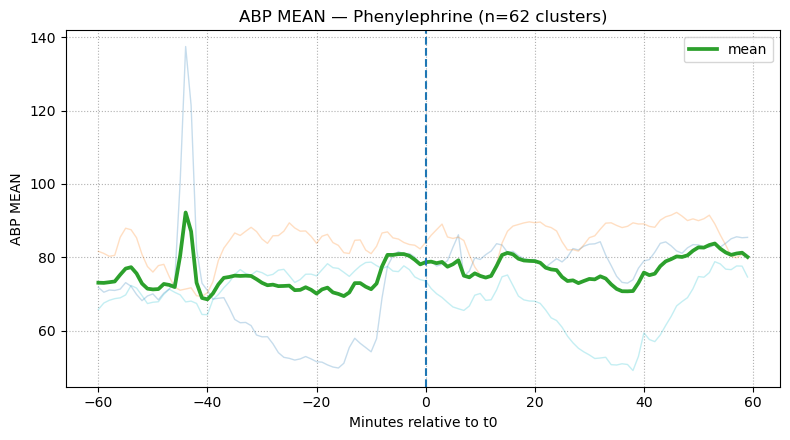

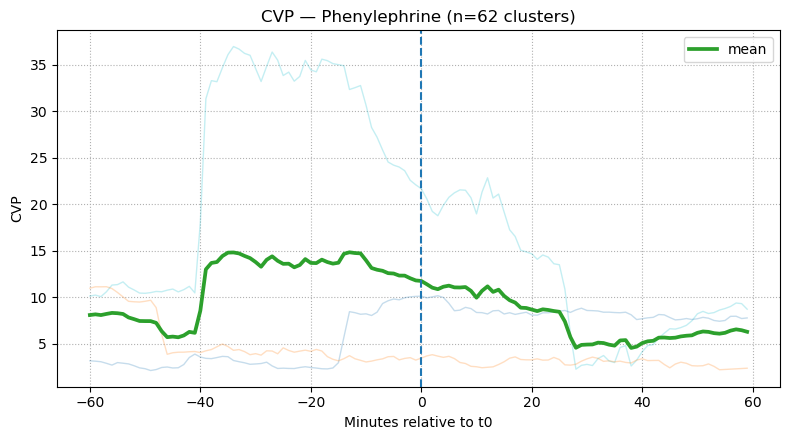

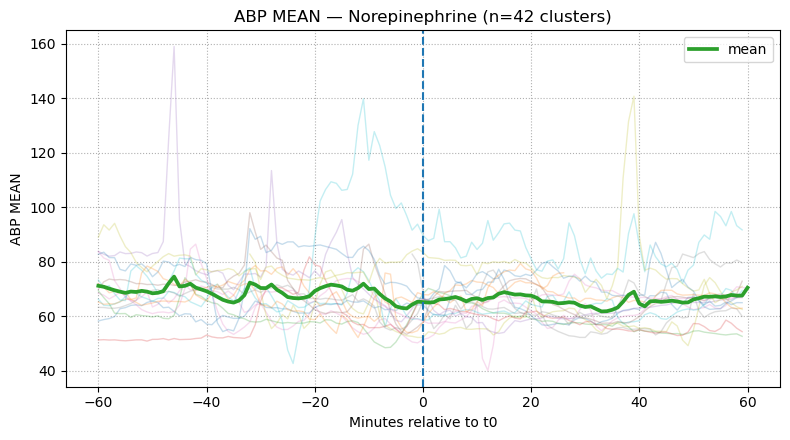

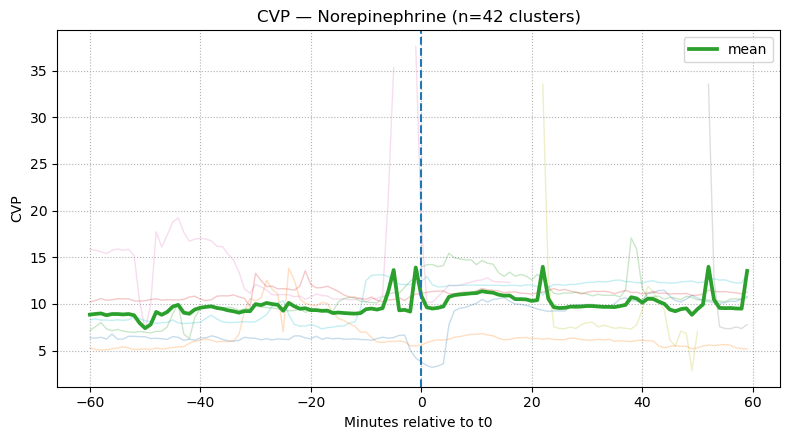

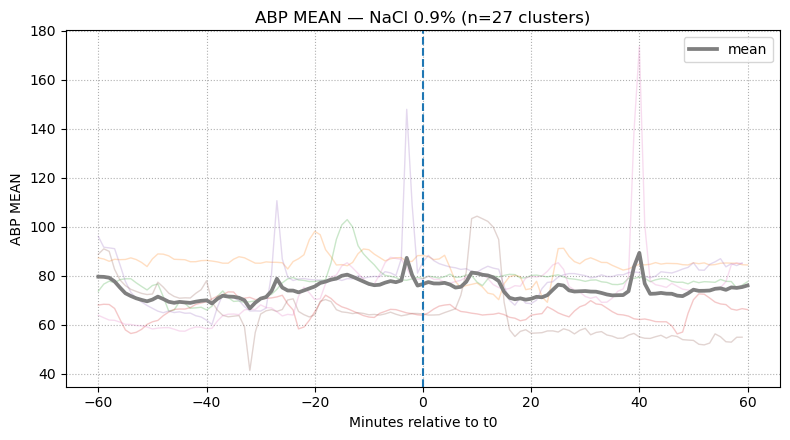

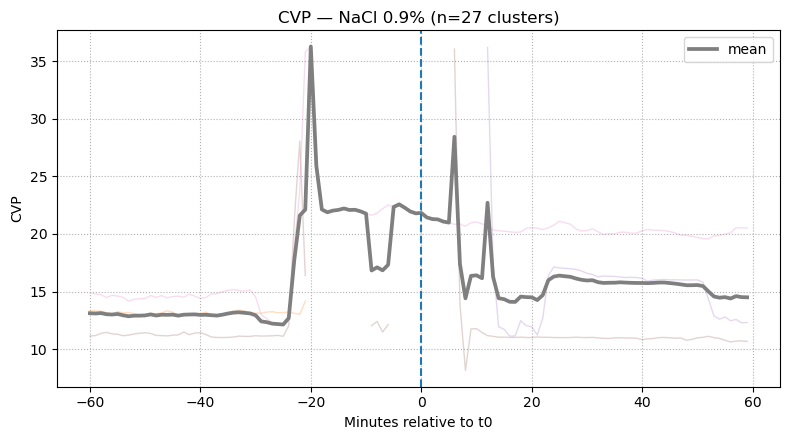

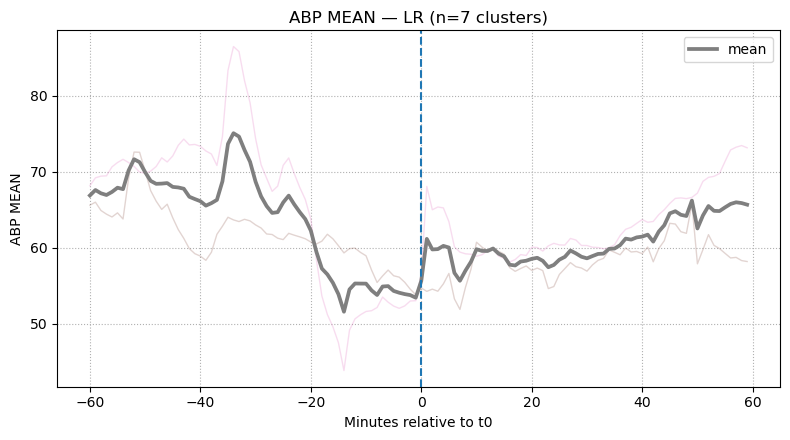

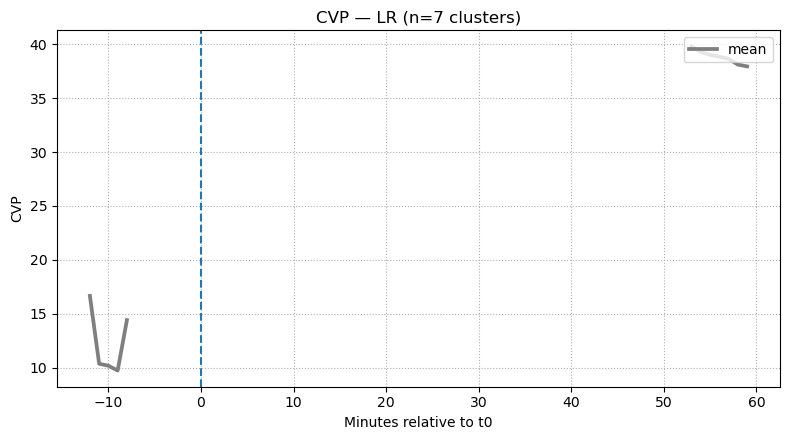

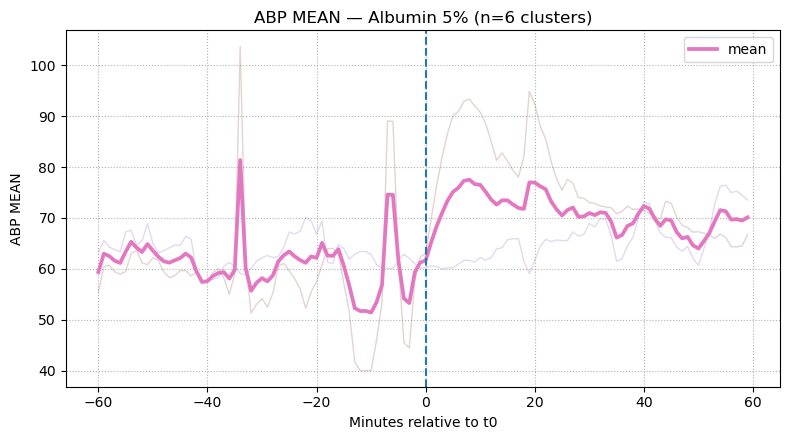

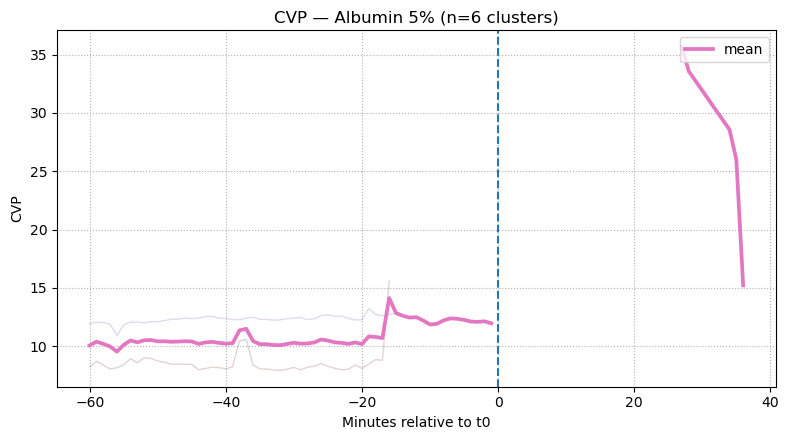

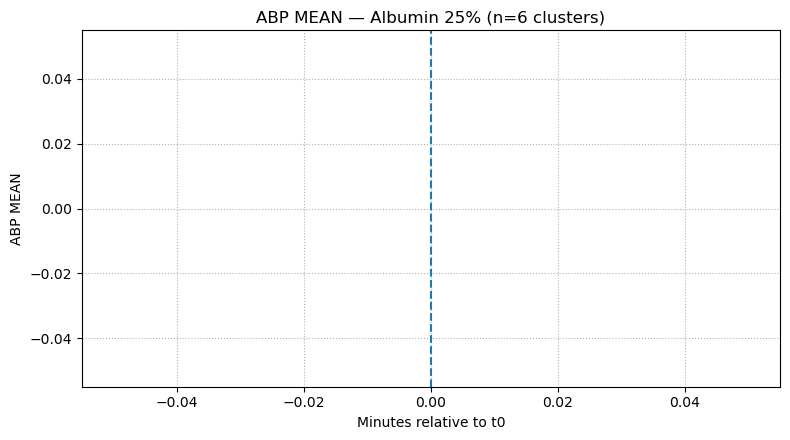

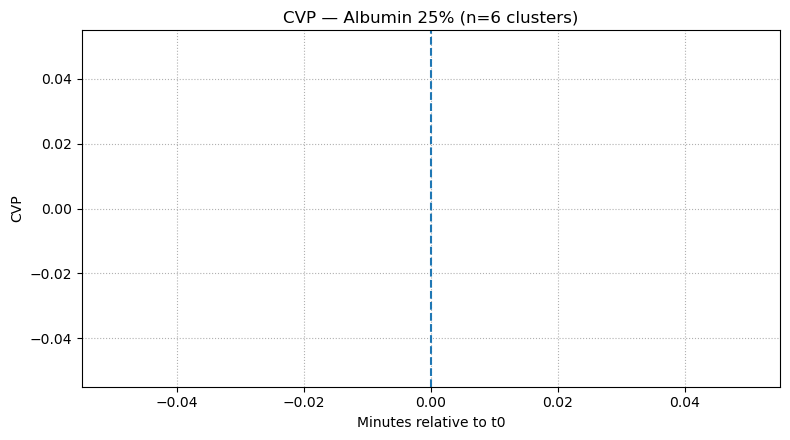

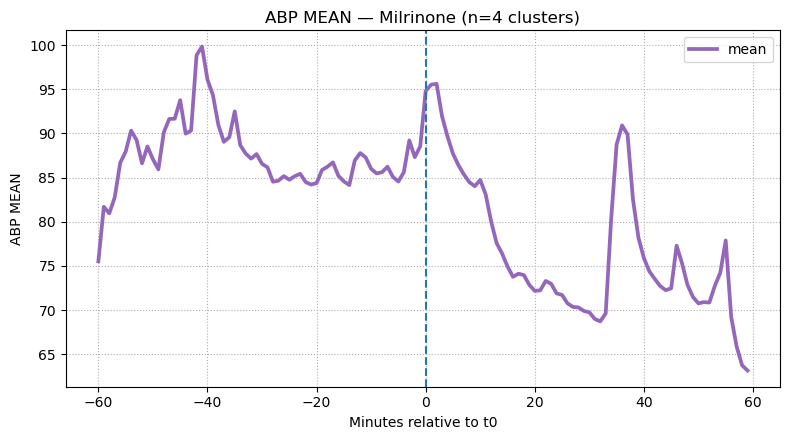

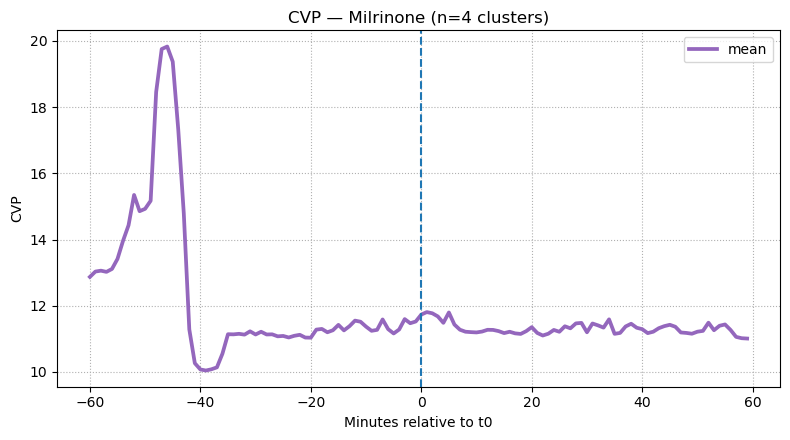

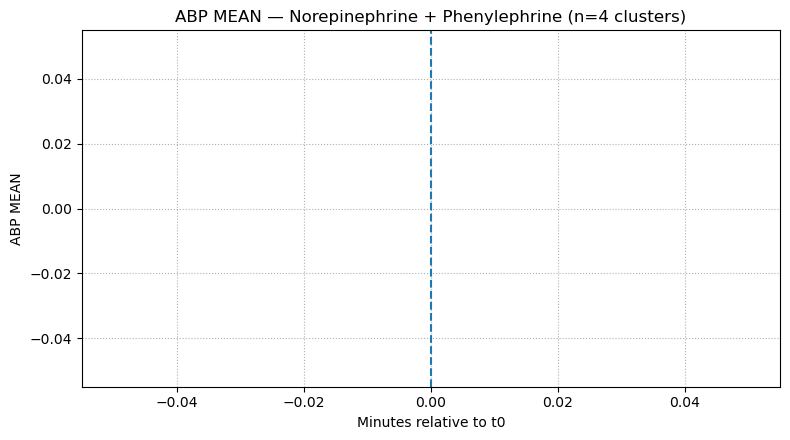

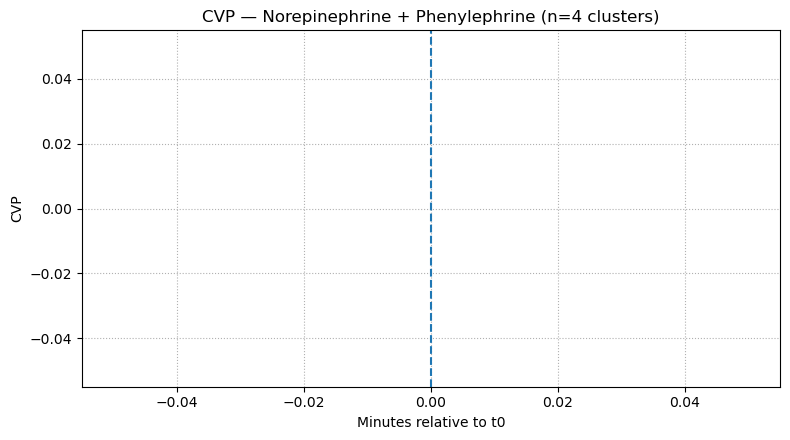

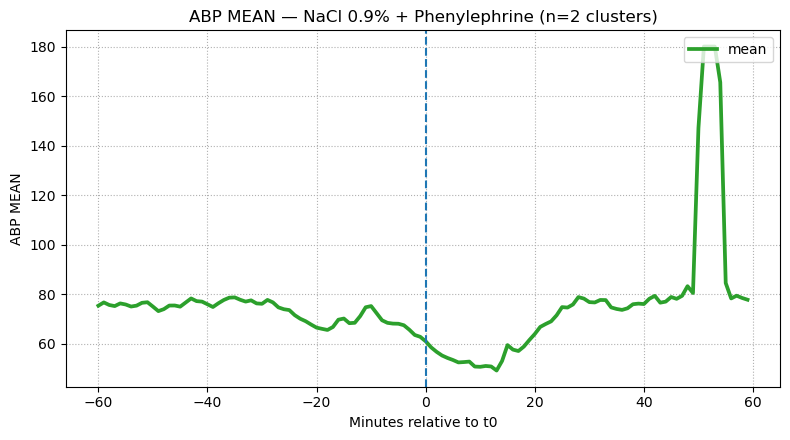

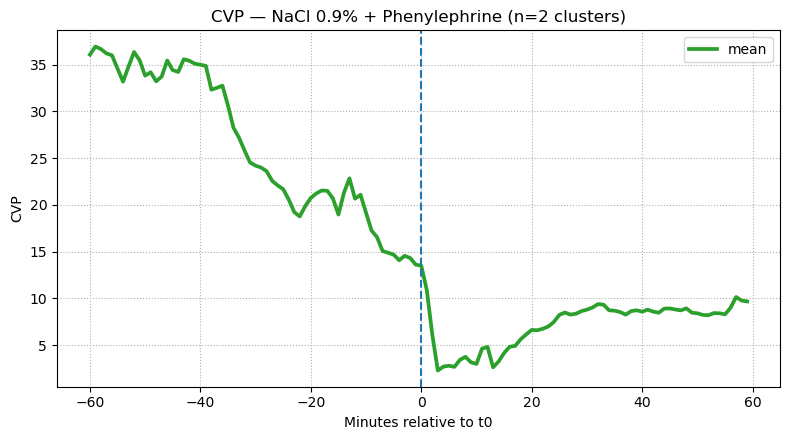

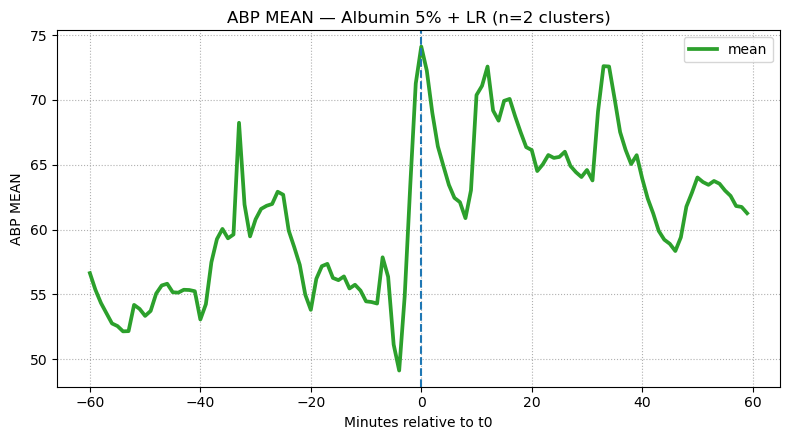

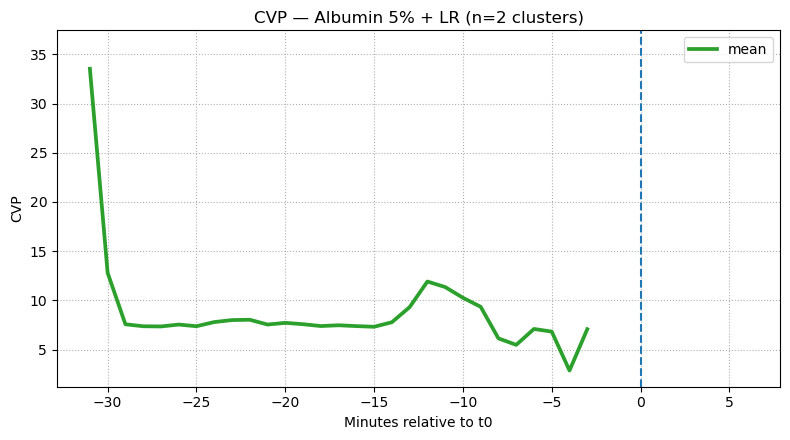

In [50]:

# 4) For each perturbation type, extract data and plot
for ctype, occ in occurrences_by_type.items():
    data = extract_aligned_windows_from_segments(
        wf_clean,
        occ,
        signals=signals,
        minutes_before=60,
        minutes_after=60,
        resample_rule="1min"
    )
    artifacts = plot_spaghetti_for_type(
        data,
        cluster_type=ctype,
        signals=signals,
        outdir="outputs_cluster_types",
        faint_alpha=0.25,
        faint_lw=1.0,
        mean_lw=2.7,
    )
    print(f"{ctype}: saved {len(artifacts)} figs")